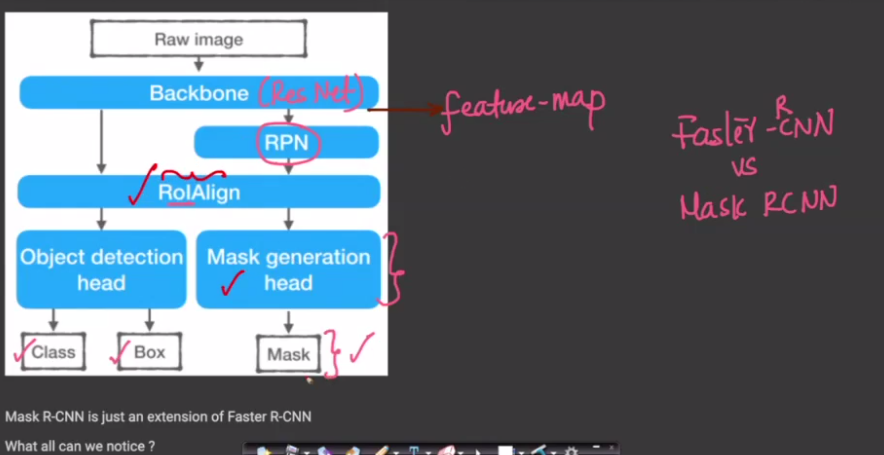

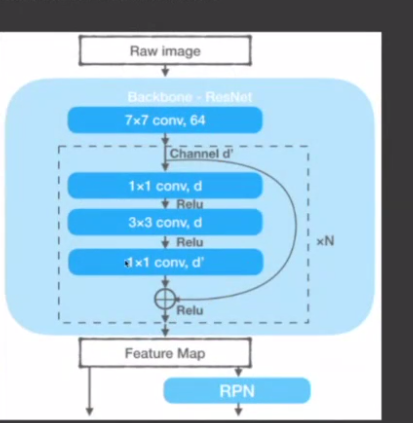

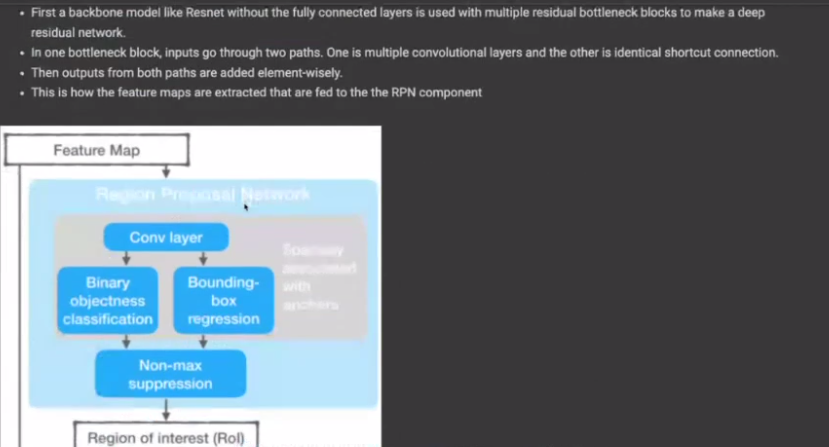

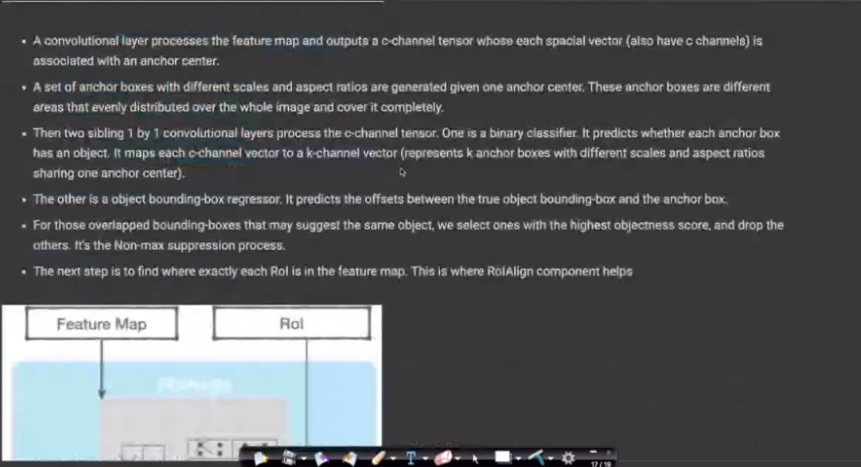

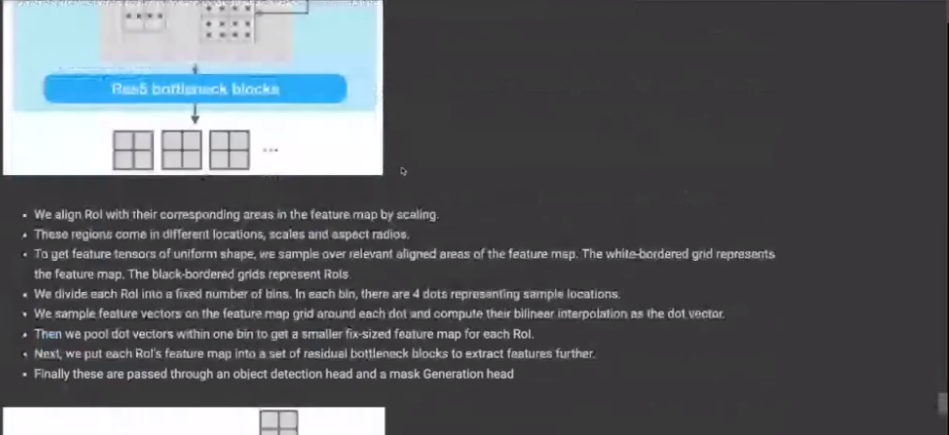

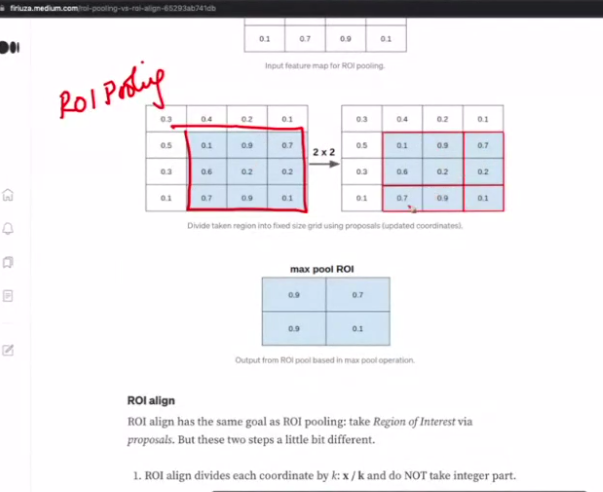

```markdown
# Mask R-CNN in Computer Vision

Mask R-CNN (Mask Region-based Convolutional Neural Network) is a state-of-the-art deep learning model for instance segmentation. It extends the Faster R-CNN object detection framework by adding a third branch for predicting an object mask in parallel with the existing branches for classification and bounding box regression.

## What is Instance Segmentation?

Instance segmentation is a computer vision task that combines elements of both object detection and semantic segmentation:

*   **Object Detection:** Identifies and localizes objects within an image by drawing a bounding box around them and classifying what object is inside.
*   **Semantic Segmentation:** Classifies each pixel in an image to a predefined class (e.g., all pixels belonging to 'car' are marked as 'car'). It doesn't distinguish between individual instances of the same class.
*   **Instance Segmentation:** Detects and localizes each *individual instance* of an object in an image and provides a pixel-level mask for each instance. For example, if there are three cars in an image, instance segmentation will identify all three as separate entities and provide a distinct mask for each.

## Architecture of Mask R-CNN

Mask R-CNN builds upon Faster R-CNN, which itself evolved from R-CNN and Fast R-CNN. The core components are:

1.  **Backbone Network:** This is typically a standard convolutional neural network (CNN), such as ResNet or ResNeXt, pre-trained on a large dataset like ImageNet. Its purpose is to extract feature maps from the input image.

2.  **Region Proposal Network (RPN):** The RPN takes the feature maps from the backbone network and proposes object candidate regions (Region of Interests, or RoIs). It predicts whether a given region contains an object and refines its bounding box coordinates.

3.  **RoIAlign Layer:** A crucial innovation in Mask R-CNN. Faster R-CNN used RoIPool, which performed quantization (rounding) that could lead to misalignment between the RoI and the original image pixels, especially for pixel-accurate tasks. RoIAlign uses bilinear interpolation to precisely align extracted features with the input, preserving spatial information.

4.  **Head Network:** For each RoI proposed by the RPN, the head network performs three parallel tasks:
    *   **Classification:** Predicts the class of the object within the RoI.
    *   **Bounding Box Regression:** Further refines the bounding box coordinates of the detected object.
    *   **Mask Prediction:** Predicts a binary mask for the object within the RoI. This mask is typically a small, fixed-size mask (e.g., 28x28 pixels) for each class, which is then resized to the original RoI dimensions.

## How Mask R-CNN Works

1.  **Feature Extraction:** An input image is passed through the backbone CNN to generate feature maps.
2.  **Region Proposals:** The RPN scans these feature maps and proposes potential bounding boxes (RoIs) where objects might be located.
3.  **Feature Alignment:** For each proposed RoI, the RoIAlign layer extracts a fixed-size feature map, ensuring precise spatial alignment.
4.  **Parallel Predictions:** These aligned feature maps are then fed into the head network, which simultaneously performs:
    *   Object classification.
    *   Bounding box refinement.
    *   Binary mask prediction for the identified object instance.

## Loss Function

The total loss function for Mask R-CNN is a multi-task loss that combines the losses from the three parallel branches:

$$L = L_{cls} + L_{box} + L_{mask}$$

*   $L_{cls}$: Classification loss (e.g., cross-entropy loss).
*   $L_{box}$: Bounding box regression loss (e.g., smooth L1 loss).
*   $L_{mask}$: Mask prediction loss (e.g., binary cross-entropy loss, applied per-pixel for each class).

## Key Advantages

*   **Instance Segmentation:** Provides pixel-level masks for each object instance, which is more detailed than bounding boxes.
*   **High Accuracy:** Achieves high accuracy on various instance segmentation benchmarks.
*   **Flexibility:** The backbone network can be easily swapped (e.g., ResNet-50, ResNeXt-101).
*   **Efficiency:** Processes images relatively fast compared to previous instance segmentation methods.
*   **Simplicity:** Extends Faster R-CNN in a straightforward manner, making it easier to implement and understand.

## Applications

Mask R-CNN has a wide range of applications in various fields:

*   **Autonomous Driving:** Detecting and segmenting pedestrians, vehicles, and other road elements for safe navigation.
*   **Medical Imaging:** Identifying and segmenting tumors, organs, and other structures for diagnosis and treatment planning.
*   **Robotics:** Enabling robots to perceive and interact with their environment by understanding individual objects.
*   **Retail Analytics:** Analyzing customer behavior, product placement, and inventory management.
*   **Image Editing and Manipulation:** Precisely selecting objects for editing, background removal, or content creation.
*   **Agriculture:** Monitoring crop health, detecting diseases, and identifying weeds.

## Conclusion

Mask R-CNN represents a significant advancement in computer vision, offering a powerful and versatile tool for instance segmentation. Its ability to provide pixel-accurate object masks has opened up new possibilities for applications requiring detailed object understanding.

**DeepLabV3**

```markdown
# DeepLabV3 in Computer Vision

DeepLabV3 is a state-of-the-art deep learning model for semantic segmentation. It builds upon previous DeepLab versions (DeepLabv1, DeepLabv2) by introducing key architectural improvements that enhance performance, particularly in handling objects at multiple scales and maintaining high-resolution feature maps.

## What is Semantic Segmentation?

Semantic segmentation is a computer vision task that involves partitioning an image into meaningful regions (segments) and assigning a class label to each pixel. Unlike object detection, which outputs bounding boxes, semantic segmentation provides a dense pixel-level classification, meaning every pixel in the image is classified as belonging to a particular category (e.g., 'car', 'road', 'sky'). It does not distinguish between individual instances of the same class.

## Key Innovations in DeepLabV3

DeepLabV3's architecture is characterized by several important innovations:

1.  **Atrous Convolution (Dilated Convolution):** This is a fundamental building block of the DeepLab series. Atrous convolution allows the convolutional filters to have a wider field of view without increasing the number of parameters or the computational cost. It achieves this by inserting zeros between kernel elements, effectively expanding the receptive field of the filter. This is crucial for capturing multi-scale context.

2.  **Atrous Spatial Pyramid Pooling (ASPP):** DeepLabV3 leverages ASPP to capture multi-scale contextual information. ASPP applies multiple parallel atrous convolutions with different rates (dilations) to the input feature map. This allows the model to sample features at various scales, enriching the understanding of objects of different sizes.

3.  **Decoder Module (for DeepLabV3+):** While DeepLabV3 focuses on an encoder-only structure, DeepLabV3+ extends it with a simple yet effective decoder module. The decoder takes the upsampled features from the ASPP module and combines them with low-level features from the backbone network. This helps to recover sharp object boundaries, which might be lost during repeated downsampling in the encoder.

4.  **Encoder-Decoder Architecture:** DeepLabV3, and especially DeepLabV3+, adopts an encoder-decoder structure. The encoder, typically a pre-trained ResNet or MobileNet, extracts high-level semantic features, often at a reduced spatial resolution. The decoder then progressively upsamples these features, integrating low-level information to produce a high-resolution segmentation map.

## How DeepLabV3 Works

1.  **Backbone Feature Extraction:** An input image is passed through a pre-trained CNN backbone (e.g., ResNet-101, MobileNetV2) to extract high-level semantic features.
2.  **Multi-Scale Context with ASPP:** The extracted features are then fed into the Atrous Spatial Pyramid Pooling (ASPP) module. ASPP applies parallel atrous convolutions with different dilation rates, as well as a 1x1 convolution and global average pooling, to capture context at various scales. The outputs are concatenated.
3.  **Feature Fusion (DeepLabV3+):** In DeepLabV3+, the output of the ASPP module is upsampled and fused with low-level features (e.g., from an earlier layer of the backbone) through concatenation. This fusion helps refine the segmentation boundaries.
4.  **Final Segmentation Map:** The fused features are then processed by a series of convolutions and upsampling layers to produce the final high-resolution semantic segmentation map, where each pixel is classified into a specific category.

## Loss Function

DeepLabV3 typically uses a pixel-wise cross-entropy loss function, which is standard for semantic segmentation tasks. It measures the difference between the predicted probability distribution for each pixel and the ground truth label.

## Key Advantages

*   **High Accuracy:** DeepLabV3 and its variants consistently achieve state-of-the-art results on various semantic segmentation benchmarks.
*   **Multi-Scale Context:** ASPP effectively captures context at different scales, enabling the model to segment objects of various sizes accurately.
*   **Sharp Boundaries:** The decoder in DeepLabV3+ helps in recovering fine details and producing sharp segmentation boundaries.
*   **Computational Efficiency:** With appropriate backbone choices (e.g., MobileNetV2), DeepLabV3 can be made computationally efficient for real-time applications.
*   **Flexibility:** The modular design allows for easy swapping of backbone networks.

## Applications

DeepLabV3 has numerous applications in computer vision:

*   **Autonomous Driving:** Understanding road scenes, identifying drivable areas, pedestrians, vehicles, and traffic signs.
*   **Medical Image Analysis:** Accurate segmentation of organs, tumors, and lesions in medical scans for diagnosis and treatment planning.
*   **Satellite Imagery Analysis:** Land cover classification, urban planning, and environmental monitoring.
*   **Robotics:** Scene understanding for robot navigation, object manipulation, and interaction.
*   **Image Editing:** Background removal, object selection, and style transfer.
*   **Augmented Reality/Virtual Reality:** Understanding the 3D environment for realistic object placement and interaction.

## Conclusion

DeepLabV3 represents a significant leap in semantic segmentation, offering robust and accurate pixel-level classification. Its innovative use of atrous convolutions and ASPP, combined with an effective encoder-decoder structure in DeepLabV3+, makes it a powerful tool for a wide range of computer vision applications.